# 15 GSEA from DE

Focused downstream preranked GSEA from the pseudobulk DE tables generated in notebook 13.

This notebook intentionally stays close to the analysis: define the cell types, comparisons, rank genes, run GSEA, and inspect pathway-level summaries.


## 1. Imports, paths and settings


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = PROJECT_ROOT / "results"

DE_DIR = RESULTS_DIR / "13_DE_pseudobulk_26donors"
GSEA_DIR = RESULTS_DIR / "15_GSEA_from_DE_26donors"
GSEA_DIR.mkdir(parents=True, exist_ok=True)

DE_SUBDIR = {
    "broad": DE_DIR / "broad",
    "excitatory_subtypes": DE_DIR / "excitatory_subtypes",
    "glia_subtypes": DE_DIR / "glia_subtypes",
}

CELL_TYPES_BY_LEVEL = {
    "broad": ["Excitatory", "Inhibitory", "Glia"],
    "excitatory_subtypes": [
        "Ex_L5_PCP4_NXPH2",
        "Ex_L5_L6_THEMIS_NR4A2",
        "Ex_L5_L6_THEMIS_TMEM233",
        "Ex_L6_TLE4_CCBE1",
        "Ex_L6_TLE4_MEGF11",
    ],
    "glia_subtypes": ["Glia_Micro"],
}

CELLTYPE_TO_LEVEL = {
    cell_type: level
    for level, cell_types in CELL_TYPES_BY_LEVEL.items()
    for cell_type in cell_types
}

COMPARISON_TO_FILE = {
    "c9ALS_vs_Control": "Control_vs_c9ALS",
    "sALS_vs_Control": "Control_vs_sALS",
    "c9ALS_vs_sALS": "sALS_vs_c9ALS",
}

GENE_SET_LIBRARY = "Reactome_2022"
MIN_RANKED_GENES = 100
TOP_N = 10
FDR_CUTOFF = 0.25

PROPOSAL_TERMS = [
    "autophagy", "lysosome", "mitochondrial", "oxidative phosphorylation",
    "immune", "inflammatory", "interferon", "vesicle", "endosome",
    "phagocytosis", "TBK1", "STING",
]

In [4]:
gsea_results = pd.read_csv(GSEA_DIR / "combined_gsea_results.csv")

term_col = "Term" if "Term" in gsea_results.columns else "Name"
fdr_col = "FDR q-val" if "FDR q-val" in gsea_results.columns else "FDR"
nes_col = "NES"

print(f"Loaded {gsea_results.shape[0]:,} GSEA rows from:")
print(GSEA_DIR / "combined_gsea_results.csv")

display(gsea_results.head())

Loaded 30,642 GSEA rows from:
/Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/15_GSEA_from_DE_26donors/combined_gsea_results.csv


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,level,cell_type,comparison,gene_set_library
0,prerank,Peptide Chain Elongation R-HSA-156902,0.796876,2.835679,0.001,0.001,0.001,68/82,15.21%,RPL38;RPL30;RPL34;RPS21;RPL37;RPS24;RPS28;RPL5...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
1,prerank,Viral mRNA Translation R-HSA-192823,0.790319,2.823377,0.001,0.001,0.001,69/85,15.21%,RPL38;RPL30;RPL34;RPS21;RPL37;RPS24;RPS28;RPL5...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
2,prerank,Nonsense Mediated Decay (NMD) Independent Of E...,0.786978,2.822680,0.001,0.001,0.001,69/88,15.21%,RPL38;RPL30;RPL34;RPS21;RPL37;RPS24;RPS28;RPL5...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
3,prerank,Selenocysteine Synthesis R-HSA-2408557,0.784564,2.819636,0.001,0.001,0.001,69/86,15.21%,RPL38;RPL30;RPL34;RPS21;RPL37;RPS24;RPS28;RPL5...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
4,prerank,Eukaryotic Translation Elongation R-HSA-156842,0.789769,2.815586,0.001,0.001,0.001,69/85,15.21%,RPL38;RPL30;RPL34;RPS21;RPL37;RPS24;RPS28;RPL5...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022


## 2. Available DE inputs


In [5]:
available_de = []

for level, cell_types in CELL_TYPES_BY_LEVEL.items():
    for cell_type in cell_types:
        for display_comparison, file_comparison in COMPARISON_TO_FILE.items():
            path = DE_SUBDIR[level] / f"{cell_type}_{file_comparison}.csv"
            available_de.append({
                "level": level,
                "cell_type": cell_type,
                "comparison": display_comparison,
                "de_file": path.name,
                "available": path.exists(),
            })

available_de = pd.DataFrame(available_de)
available_de


,level,cell_type,comparison,de_file,available
0,broad,Excitatory,c9ALS_vs_Control,Excitatory_Control_vs_c9ALS.csv,True
1,broad,Excitatory,sALS_vs_Control,Excitatory_Control_vs_sALS.csv,True
2,broad,Excitatory,c9ALS_vs_sALS,Excitatory_sALS_vs_c9ALS.csv,True
3,broad,Inhibitory,c9ALS_vs_Control,Inhibitory_Control_vs_c9ALS.csv,True
4,broad,Inhibitory,sALS_vs_Control,Inhibitory_Control_vs_sALS.csv,True
5,broad,Inhibitory,c9ALS_vs_sALS,Inhibitory_sALS_vs_c9ALS.csv,True
6,broad,Glia,c9ALS_vs_Control,Glia_Control_vs_c9ALS.csv,True
7,broad,Glia,sALS_vs_Control,Glia_Control_vs_sALS.csv,True
8,broad,Glia,c9ALS_vs_sALS,Glia_sALS_vs_c9ALS.csv,True
9,excitatory_subtypes,Ex_L5_PCP4_NXPH2,c9ALS_vs_Control,Ex_L5_PCP4_NXPH2_Control_vs_c9ALS.csv,True


## 3. Run preranked GSEA

```text
c9ALS_vs_Control: positive rank = higher in c9ALS than Control
sALS_vs_Control: positive rank = higher in sALS than Control
c9ALS_vs_sALS: positive rank = higher in c9ALS than sALS
```


In [11]:
if gp is None:
    raise ModuleNotFoundError(
        "gseapy is required for this notebook. Install it in the notebook environment with: python -m pip install gseapy"
    )

all_gsea_results = []
skipped = []

for _, row in available_de.query("available").iterrows():
    level = row["level"]
    cell_type = row["cell_type"]
    comparison = row["comparison"]
    file_comparison = COMPARISON_TO_FILE[comparison]
    de_path = DE_SUBDIR[level] / f"{cell_type}_{file_comparison}.csv"

    de = pd.read_csv(de_path)
    de["gene"] = de["gene"].astype(str)

    if "stat" in de.columns:
        rank_df = de[["gene", "stat"]].rename(columns={"stat": "rank_score"}).copy()
    else:
        rank_df = de[["gene", "log2FoldChange", "pvalue"]].copy()
        rank_df["rank_score"] = np.sign(rank_df["log2FoldChange"]) * -np.log10(rank_df["pvalue"].clip(lower=1e-300))
        rank_df = rank_df[["gene", "rank_score"]]

    rank_df = (
        rank_df
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .groupby("gene", as_index=False)["rank_score"].max()
        .sort_values("rank_score", ascending=False)
    )

    if rank_df.shape[0] < MIN_RANKED_GENES:
        skipped.append({"cell_type": cell_type, "comparison": comparison, "reason": "too_few_ranked_genes"})
        continue

    print(f"Running GSEA: {cell_type} | {comparison} | {rank_df.shape[0]} ranked genes")

    pre_res = gp.prerank(
        rnk=rank_df,
        gene_sets=GENE_SET_LIBRARY,
        min_size=15,
        max_size=500,
        permutation_num=1000,
        seed=1,
        outdir=None,
        verbose=False,
    )

    res = pre_res.res2d.copy()
    res["level"] = level
    res["cell_type"] = cell_type
    res["comparison"] = comparison
    res["gene_set_library"] = GENE_SET_LIBRARY

    result_path = GSEA_DIR / f"{cell_type}_{comparison}_{GENE_SET_LIBRARY}_gsea.csv"
    res.to_csv(result_path, index=False)

    all_gsea_results.append(res)

if skipped:
    display(pd.DataFrame(skipped))

if not all_gsea_results:
    raise ValueError("No GSEA results were generated. Check DE files, internet access, and gene-set library availability.")

gsea_results = pd.concat(all_gsea_results, ignore_index=True)
gsea_results.to_csv(GSEA_DIR / "combined_gsea_results.csv", index=False)

gsea_results.head()


2026-06-06 22:13:39,753 [WARNING] Duplicated values found in preranked stats: 15.95% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA: Excitatory | c9ALS_vs_Control | 41572 ranked genes


2026-06-06 22:14:21,983 [WARNING] Duplicated values found in preranked stats: 18.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA: Excitatory | sALS_vs_Control | 40283 ranked genes


2026-06-06 22:15:02,261 [WARNING] Duplicated values found in preranked stats: 16.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

2026-06-06 22:25:46,655 [WARNING] Duplicated values found in preranked stats: 31.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA: Glia_Micro | sALS_vs_Control | 26823 ranked genes


2026-06-06 22:26:12,702 [WARNING] Duplicated values found in preranked stats: 31.79% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Running GSEA: Glia_Micro | c9ALS_vs_sALS | 27446 ranked genes


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,level,cell_type,comparison,gene_set_library
0,prerank,Peptide Chain Elongation R-HSA-156902,0.796158,2.857602,0.0,0.0,0.0,65/82,13.06%,RPL38;RPS12;RPL21;RPS24;RPS27A;RPL36AL;RPL37;R...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
1,prerank,Formation Of A Pool Of Free 40S Subunits R-HSA...,0.779209,2.848945,0.0,0.0,0.0,69/94,13.06%,RPL38;RPS12;RPL21;RPS24;RPS27A;RPL36AL;RPL37;R...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
2,prerank,Viral mRNA Translation R-HSA-192823,0.7925,2.842232,0.0,0.0,0.0,66/85,13.06%,RPL38;RPS12;RPL21;RPS24;RPS27A;RPL36AL;RPL37;R...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
3,prerank,Eukaryotic Translation Termination R-HSA-72764,0.785315,2.840426,0.0,0.0,0.0,66/86,13.06%,RPL38;RPS12;RPL21;RPS24;RPS27A;RPL36AL;RPL37;R...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022
4,prerank,L13a-mediated Translational Silencing Of Cerul...,0.761246,2.836927,0.0,0.0,0.0,70/103,13.06%,RPL38;RPS12;RPL21;RPS24;RPS27A;RPL36AL;RPL37;R...,broad,Excitatory,c9ALS_vs_Control,Reactome_2022


## 4. Top enriched pathways


In [6]:
term_col = "Term" if "Term" in gsea_results.columns else "Name"
fdr_col = "FDR q-val" if "FDR q-val" in gsea_results.columns else "FDR"
nes_col = "NES"

gsea_summary = (
    gsea_results
    .sort_values(["cell_type", "comparison", fdr_col, nes_col], ascending=[True, True, True, False])
    .groupby(["level", "cell_type", "comparison"], as_index=False)
    .head(TOP_N)
)

gsea_summary.to_csv(GSEA_DIR / "top_gsea_pathways_summary.csv", index=False)

gsea_summary[["level", "cell_type", "comparison", term_col, nes_col, fdr_col]].head(40)


,level,cell_type,comparison,Term,NES,FDR q-val
17089,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Defective B3GAT3 Causes JDSSDHD R-HSA-3560801,-2.287376,0.001000
17088,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,"Defective B4GALT7 Causes EDS, Progeroid Type R...",-2.295861,0.001000
17087,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Signaling By NTRKs R-HSA-166520,-2.319887,0.001000
17086,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Signaling By NTRK1 (TRKA) R-HSA-187037,-2.347450,0.001000
17085,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,G-protein Mediated Events R-HSA-112040,-2.358439,0.001000
17084,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Integration Of Energy Metabolism R-HSA-163685,-2.387162,0.001000
17083,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Opioid Signaling R-HSA-111885,-2.443266,0.001000
17090,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,RAF-independent MAPK1/3 Activation R-HSA-112409,-2.262543,0.001191
17096,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Regulation Of Insulin Secretion R-HSA-422356,-2.169302,0.003175
17095,excitatory_subtypes,Ex_L5_L6_THEMIS_NR4A2,c9ALS_vs_Control,Nuclear Events (Kinase And Transcription Facto...,-2.187340,0.003175


## 5. Plot top pathways for one result


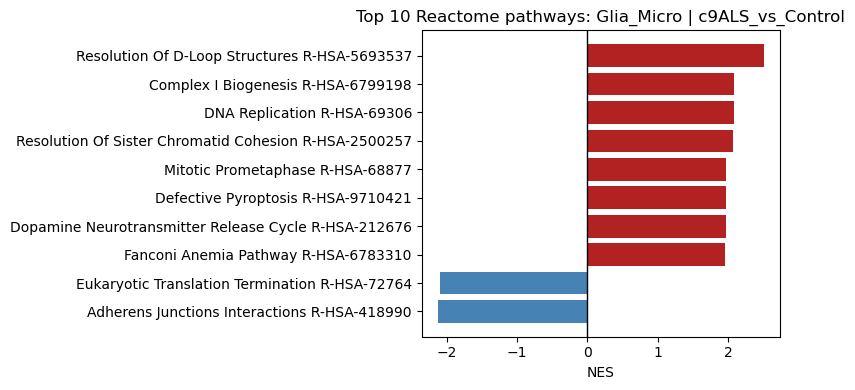

In [7]:
plot_cell_type = "Glia_Micro"
plot_comparison = "c9ALS_vs_Control"

plot_df = (
    gsea_results
    .query("cell_type == @plot_cell_type and comparison == @plot_comparison")
    .sort_values(fdr_col)
    .head(TOP_N)
    .sort_values(nes_col)
)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
colors = np.where(plot_df[nes_col] >= 0, "firebrick", "steelblue")
ax.barh(plot_df[term_col], plot_df[nes_col], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("NES")
ax.set_title(f"Top {TOP_N} Reactome pathways: {plot_cell_type} | {plot_comparison}")
plt.tight_layout()
plt.show()


## 6. Proposal-relevant pathway view


In [8]:
pattern = "|".join(PROPOSAL_TERMS)
proposal_relevant = gsea_results[
    gsea_results[term_col].astype(str).str.contains(pattern, case=False, na=False)
].copy()

proposal_relevant = proposal_relevant.sort_values([fdr_col, nes_col], ascending=[True, False])
proposal_relevant.to_csv(GSEA_DIR / "proposal_relevant_gsea_pathways.csv", index=False)

proposal_relevant[["level", "cell_type", "comparison", term_col, nes_col, fdr_col]].head(50)


,level,cell_type,comparison,Term,NES,FDR q-val
2343,broad,Excitatory,c9ALS_vs_sALS,Mitochondrial Translation Termination R-HSA-54...,2.836319,0.001
2345,broad,Excitatory,c9ALS_vs_sALS,Mitochondrial Translation Initiation R-HSA-536...,2.816287,0.001
2347,broad,Excitatory,c9ALS_vs_sALS,Mitochondrial Translation Elongation R-HSA-538...,2.801453,0.001
2348,broad,Excitatory,c9ALS_vs_sALS,Mitochondrial Translation R-HSA-5368287,2.776882,0.001
2351,broad,Excitatory,c9ALS_vs_sALS,Mitochondrial Protein Import R-HSA-1268020,2.635351,0.001
15996,excitatory_subtypes,Ex_L5_PCP4_NXPH2,c9ALS_vs_sALS,Mitochondrial Translation Termination R-HSA-54...,2.578108,0.001
15999,excitatory_subtypes,Ex_L5_PCP4_NXPH2,c9ALS_vs_sALS,Mitochondrial Translation Elongation R-HSA-538...,2.557002,0.001
16000,excitatory_subtypes,Ex_L5_PCP4_NXPH2,c9ALS_vs_sALS,Mitochondrial Translation R-HSA-5368287,2.550844,0.001
16001,excitatory_subtypes,Ex_L5_PCP4_NXPH2,c9ALS_vs_sALS,Mitochondrial Translation Initiation R-HSA-536...,2.536023,0.001
22744,excitatory_subtypes,Ex_L5_L6_THEMIS_TMEM233,c9ALS_vs_sALS,Mitochondrial Translation Elongation R-HSA-538...,2.535097,0.001


## Interpretation note

NES is the normalised enrichment score.

- Positive NES means the pathway is enriched among genes upregulated in the numerator condition. For example, `c9ALS_vs_Control` with positive NES means enrichment toward genes higher in c9ALS relative to Control.
- Negative NES means the pathway is enriched among genes downregulated in the numerator condition.
- GSEA provides pathway-level transcriptomic evidence. It is not direct evidence of protein abundance, protein interaction, or pathway activity.
